### 📄 [Click here to view Lab 2 PDF](https://github.com/Fawaz-Alshahrani/Image_Processing/blob/main/lab%202.pdf)

In [ ]:
%pip install opencv-python

In [5]:
%pip install matplotlib pillow

  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 1.5 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/9.3 MB 1.4 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.3 MB 1.4 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.3 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.3 MB 1.2 MB/s eta 0:00:07
   ------ --------------------------------- 1.6/9.3 MB 1.2 MB/s eta 0:00:07
   ------- -------------------------------- 1.8/9.3 MB 1.2 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/9.3

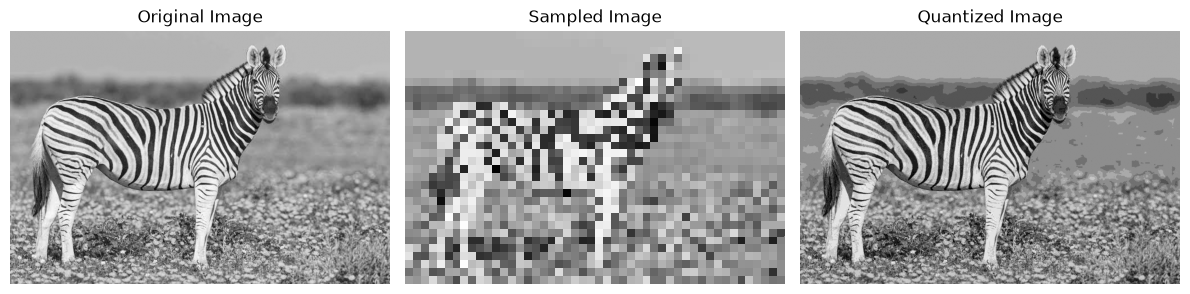

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image_path = r"C:\Lab3\Zebra_image.jpeg"
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

def sample_image(image, factor):
    height, width = image.shape[:2]
    return cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)

def quantize_image(image, levels):
    step = 256 // levels
    quantized_image = np.floor(image / step) * step
    return quantized_image.astype(np.uint8)

def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

sampled_image = sample_image(original_image, 14)
quantized_image = quantize_image(original_image, 9)

plot_images(original_image, sampled_image, quantized_image)

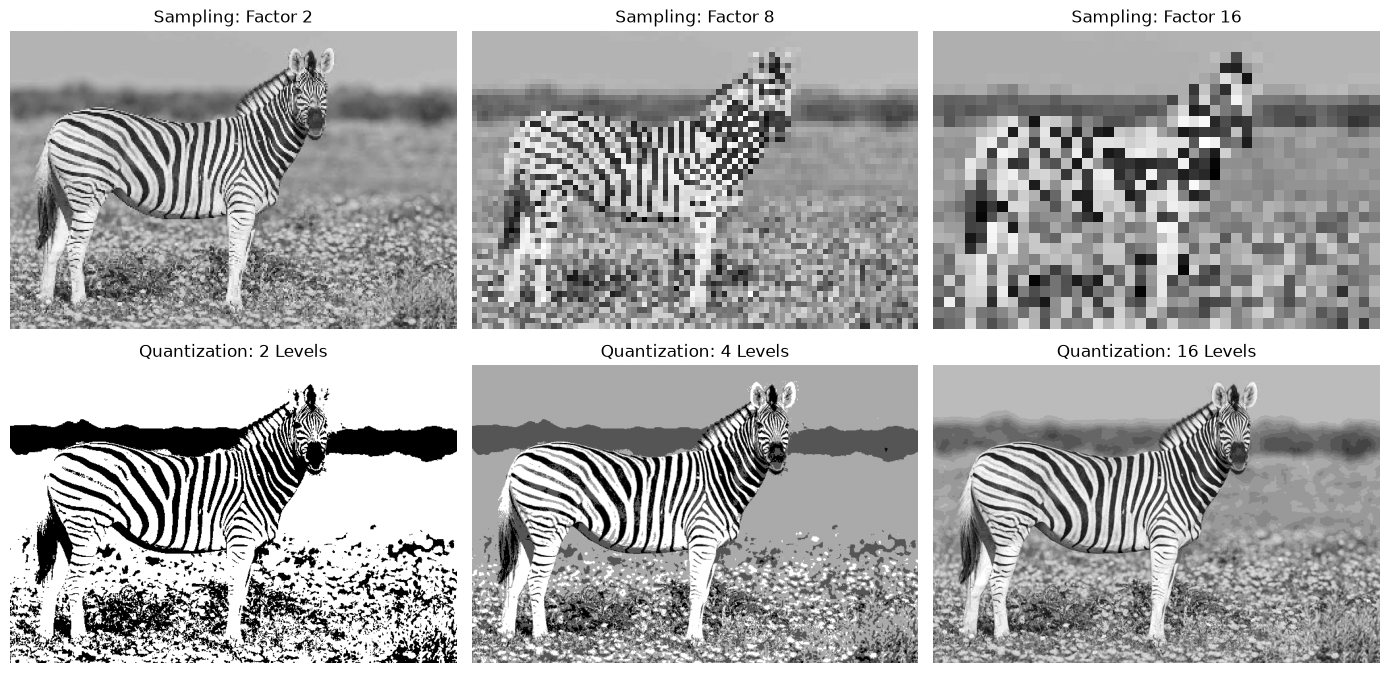

In [12]:
factors = [2, 8, 16]
levels = [2, 4, 16]

plt.figure(figsize=(14, 7))

for i, factor in enumerate(factors, 1):
    downsampled = sample_image(original_image, factor)
    plt.subplot(2, 3, i)
    plt.imshow(downsampled, cmap='gray')
    plt.title(f'Sampling: Factor {factor}')
    plt.axis('off')

for i, level in enumerate(levels, 4):
    quantized = quantize_image(original_image, level)
    plt.subplot(2, 3, i)
    plt.imshow(quantized, cmap='gray')
    plt.title(f'Quantization: {level} Levels')
    plt.axis('off')

plt.tight_layout()
plt.show()

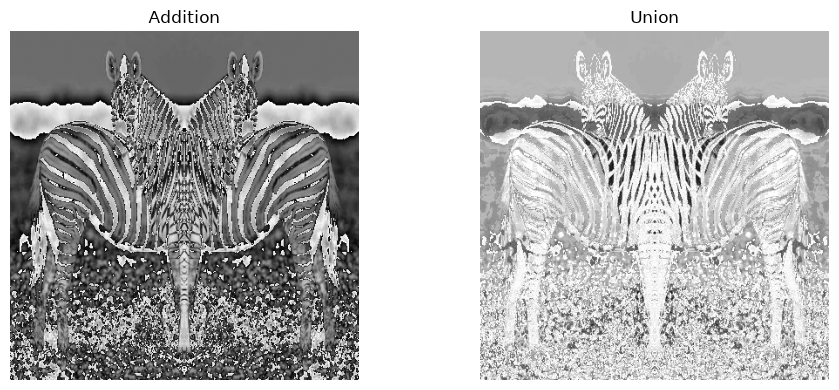

In [13]:
img1 = cv2.resize(original_image, (400, 400))
img2 = cv2.flip(img1, 1)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
union = im1arr | im2arr

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(addition, cmap='gray')
plt.title('Addition')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(union, cmap='gray')
plt.title('Union')
plt.axis('off')

plt.tight_layout()
plt.show()

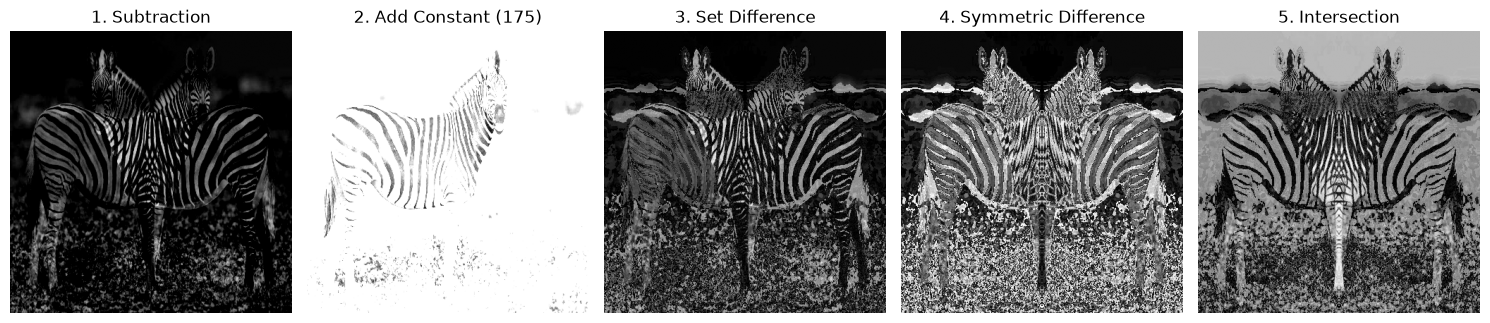

In [14]:
im1_int = img1.astype(np.int16)
im2_int = img2.astype(np.int16)

subtracted = np.clip(im1_int - im2_int, 0, 255).astype(np.uint8)
add_175 = np.clip(im1_int + 175, 0, 255).astype(np.uint8)
set_diff = img1 & (~img2)
sym_diff = img1 ^ img2
intersection = img1 & img2

outputs = [
    ("1. Subtraction", subtracted),
    ("2. Add Constant (175)", add_175),
    ("3. Set Difference", set_diff),
    ("4. Symmetric Difference", sym_diff),
    ("5. Intersection", intersection)
]

plt.figure(figsize=(15, 6))
for idx, (title, img_data) in enumerate(outputs, 1):
    plt.subplot(1, 5, idx)
    plt.imshow(img_data, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()